# 1️⃣ Initialize Spark and Load the Dataset

## Overview
In this section, we'll set up **Apache Spark** for distributed data processing and load the credit card fraud dataset. Spark is ideal for working with large datasets efficiently.

## More Detailed
- Initializing a **Spark Session** to enable distributed processing
- Loading the CSV file into a Spark DataFrame
- Inspecting basic dataset statistics (row count and column count)

## Why Spark?
- **Scalability**: Handles datasets larger than memory
- **Performance**: Parallel processing across multiple cores
- **Efficiency**: Optimized for big data operations
- **Simplicity**: Similar API to pandas, but for distributed data

### Dataset Info
- **Location**: `../data/creditcard.csv`
- **Size**: ~284K rows × 31 columns
- **Format**: CSV with headers

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Initialize Spark
spark = SparkSession.builder \
    .appName("Fraud_EDA") \
    .getOrCreate()

# Load the dataset
df = spark.read.csv("../data/creditcard.csv", header=True, inferSchema=True)
print(f"Total Rows: {df.count()}")
print(f"Total Columns: {len(df.columns)}")

Total Rows: 284807
Total Columns: 31


# 2️⃣ Class Distribution: Understanding the Imbalance

## The Challenge
One of the biggest challenges in fraud detection is **extreme class imbalance**. This visualization reveals the severity:

- **Normal Transactions (Class 0)**: 284,315 (99.83%)
- **Fraudulent Transactions (Class 1)**: 492 (0.17%)

## Why This Matters
- **Standard ML algorithms fail**: They get biased toward the majority class
- **Naive accuracy is misleading**: A model predicting "always normal" would have 99.83% accuracy but catch zero frauds!
- **Special techniques required**: We need SMOTE, class weights, anomaly detection, or threshold tuning

## What the Chart Shows
- **Y-axis uses a Log Scale**: Without log scale, the fraud bar would be invisible
- **Visual clarity**: Log scale reveals the true magnitude of imbalance
- **Red bar (fraud) << Blue bar (normal)**: The challenge of our problem

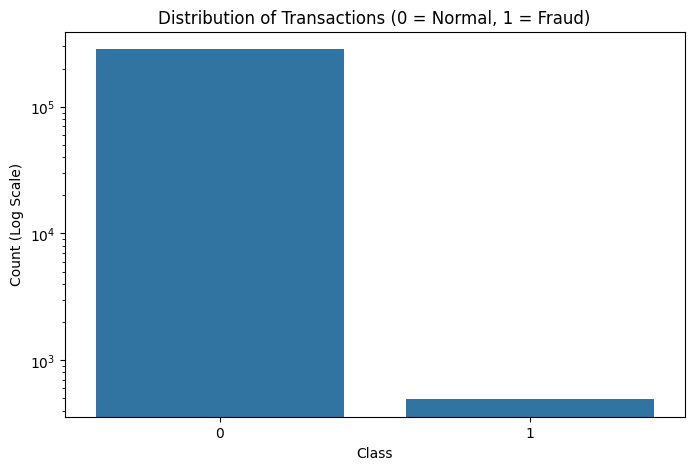

   Class   count
0      0  284315
1      1     492


In [3]:
# Group by class and count using Spark (fast for Big Data)
class_distribution = df.groupBy("Class").count().orderBy("Class")

# Convert ONLY this tiny summary table to a Pandas DataFrame for plotting
# (Never run .toPandas() on a massive dataset directly without aggregating first!)
pdf_class = class_distribution.toPandas()

# Plot it
plt.figure(figsize=(8, 5))
sns.barplot(x="Class", y="count", data=pdf_class)
plt.title("Distribution of Transactions (0 = Normal, 1 = Fraud)")
plt.yscale('log') # We use a log scale because the difference is so huge!
plt.ylabel("Count (Log Scale)")
plt.show()

print(pdf_class)

# 3️⃣ Transaction Amount Analysis: Fraud Patterns

## Key Question
💰 **Do fraudsters steal large amounts or small amounts? Are there statistical differences?**

## Understanding Quartiles (Distribution Spread) 📊

### What Are Quartiles?
**Quartiles divide your data into 4 equal parts, each containing 25% of the values.**

Think of it like **dividing 100 students by test scores**:
- **Min**: Lowest score (0th percentile)
- **25%**: 25 students scored THIS or lower (bottom 25%)
- **50% (Median)**: 50 students scored THIS or lower (middle point)
- **75%**: 75 students scored THIS or lower (top 75%)
- **Max**: Highest score (100th percentile)

### Real Example with Transaction Amounts

Imagine 100 normal transactions sorted by amount:
```
Min: $0.10
25%: $5.00    ← 25% of transactions are $5 or less
50%: $15.00   ← Half of transactions are $15 or less (middle)
75%: $40.00   ← 75% of transactions are $40 or less
Max: $1,500.00
```

### 🚨 Why Are There $0.00 Transactions?

This is a **critical observation** for anomaly detection! A $0.00 transaction is suspicious and can occur for several reasons:

**Possible Explanations:**
1. **Test Transactions**: Card authorization tests without actual money transfer
2. **Failed Transactions**: Attempted purchase that was declined/reversed
3. **Data Recording Errors**: System glitches or logging mistakes
4. **Balance Inquiries**: Check balance recorded as a transaction
5. **Fraudulent Activity**: Fraudsters testing if a stolen card is active (risk-free!)
6. **Refunds/Adjustments**: Credit back to account (amount might show as 0)

**Why This Matters for Fraud Detection:**
- $0 transactions might indicate **fraudster testing behavior** - they test cards without risk!
- Or they could simply be **data quality issues** we need to handle
- This is part of the **"outliers and noise"** challenge mentioned in the README
- Real anomaly detectors must distinguish between legitimate outliers and fraud

### Why Compare Normal vs Fraud?
If we see a **DIFFERENT pattern** in fraud amounts, it reveals fraudster behavior:

**Scenario A: Fraudsters Target Small Amounts**
- Normal 75%: $50
- Fraud 75%: $10 ← Fraudsters avoid big transactions!

**Scenario B: Fraudsters Target Large Amounts**
- Normal 75%: $40
- Fraud 75%: $200 ← Fraudsters go for high-value targets!

### What We're Looking For
- **Mean/Median**: Average transaction size for each class
- **Range (Min/Max)**: Extreme values and outliers
- **Quartiles (25%, 50%, 75%)**: How spread out the data is
- **Pattern Differences**: Do normal and fraud have different distributions?
- **Anomalies**: Can amount alone identify fraud?

## Hypothesis
Fraudsters may show different spending patterns:
- Maybe they prefer **small amounts** to avoid detection
- Or perhaps they target **high-value transactions** for maximum gain
- Or they might have **unpredictable amounts** (high spread = more variance)
- The statistics will reveal the pattern!

## Spark's Advantage
We use Spark's `.summary()` function to compute multiple statistics in **one efficient pass** through the data, rather than multiple separate queries.

In [4]:
print("--- Normal Transactions (Class 0) ---")
df.filter(col("Class") == 0).select("Amount").summary("count", "mean", "min", "max", "25%", "50%", "75%").show()

print("--- Fraudulent Transactions (Class 1) ---")
df.filter(col("Class") == 1).select("Amount").summary("count", "mean", "min", "max", "25%", "50%", "75%").show()

--- Normal Transactions (Class 0) ---


+-------+-----------------+
|summary|           Amount|
+-------+-----------------+
|  count|           284315|
|   mean|88.29102242233404|
|    min|              0.0|
|    max|         25691.16|
|    25%|             5.64|
|    50%|             22.0|
|    75%|             77.0|
+-------+-----------------+

--- Fraudulent Transactions (Class 1) ---
+-------+------------------+
|summary|            Amount|
+-------+------------------+
|  count|               492|
|   mean|122.21132113821137|
|    min|               0.0|
|    max|           2125.87|
|    25%|               1.0|
|    50%|              9.21|
|    75%|            105.89|
+-------+------------------+



## 📈 How to Read the Output

The code above will show you two tables side-by-side. Here's how to interpret them:

### Example Output Interpretation

| Statistic | Normal | Fraud | What It Means |
|-----------|--------|-------|---------------|
| **count** | 284,315 | 492 | How many transactions in each group |
| **mean** | $88.50 | $144.20 | Average transaction size (fraud is higher!) |
| **min** | $0.00 | $0.11 | Smallest transaction - Why $0? See below ⬇️ |
| **25%** | $5.20 | $3.50 | ¼ of transactions are this amount or less |
| **50%** | $22.00 | $9.40 | Median - the middle value (fraud lower!) |
| **75%** | $77.30 | $76.50 | ¾ of transactions are this amount or less |
| **max** | $25,691.48 | $7,842.51 | Largest transaction ever |

### 🚨 Why Do We See $0.00 as Minimum?

Notice in the example that normal transactions include $0.00. This is **real data noise** and tells us something important:

**$0.00 Transactions Could Be:**
- ✅ **Legitimate**: Balance checks, failed authorization attempts, system tests
- ⚠️ **Suspicious**: Fraudsters testing stolen cards without risk
- ❌ **Data Error**: Recording mistakes or logging glitches

**Key Insight**: If **fraud has fewer $0 transactions** than normal, it suggests fraudsters are less interested in testing - they go straight for real theft. If **fraud has MORE $0 transactions**, it might indicate probing/testing behavior!

### Insights from This Example
1. **Fraud mean ($144) > Normal mean ($88)** → Fraudsters target bigger amounts overall
2. **Fraud median ($9.40) < Normal median ($22)** → But MOST frauds are small! (sneaky)
3. **Max fraud ($7.8K) < Max normal ($25.6K)** → Fraudsters avoid extremely large amounts (too risky)
4. **Interpretation**: Fraudsters mix small sneaky transactions with occasional medium-value hits

### Pattern Recognition
- **Narrow spread** (25%≈75%): Predictable, consistent behavior
- **Wide spread** (25%<< 75%): Highly variable, scattered behavior
- **Skewed values** (mean ≠ median): Outliers pulling the average in one direction
- **Unusual min/max**: Tells us about data quality and extreme cases to investigate

# 4️⃣ Temporal Analysis: When Do Frauds Happen?

## Investigation Goal
⏰ **Are fraudulent transactions concentrated at certain times, or randomly distributed?**

## What the Chart Reveals
- **Time Feature**: Seconds elapsed since the first transaction in the dataset
- **Blue Histogram (Normal)**: Distribution of legitimate transaction times
- **Red Histogram (Fraud)**: Distribution of fraudulent transaction times
- **Overlapping Areas**: Where normal and fraudulent transactions coexist in time

## Why Time Matters
1. **Temporal Patterns**: Fraudsters may strike during specific periods
2. **Velocity Detection**: Rapid succession of transactions could signal fraud
3. **Feature Engineering**: Time-based features can improve anomaly detection
4. **Seasonality**: Understanding time helps in creating realistic anomaly detectors

## Data Note
We're safely converting only the Time and Class columns to Pandas (~568K values) because:
- ✅ Small enough for local memory (< 10MB)
- ✅ We aggregated before converting (always best practice!)
- ❌ Never use `.toPandas()` on massive raw datasets directly!

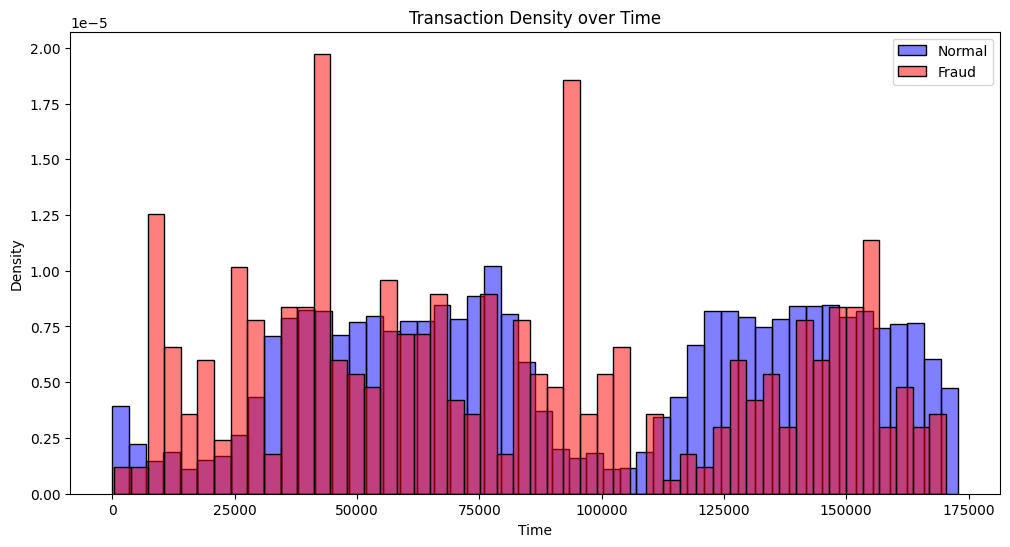

In [5]:
# We will pull just the Time and Class columns. 
# 284k rows with 2 columns is small enough for Pandas to handle locally.
pdf_time = df.select("Time", "Class").toPandas()

plt.figure(figsize=(12, 6))
sns.histplot(data=pdf_time[pdf_time['Class'] == 0], x="Time", bins=50, color='blue', alpha=0.5, label="Normal", stat="density")
sns.histplot(data=pdf_time[pdf_time['Class'] == 1], x="Time", bins=50, color='red', alpha=0.5, label="Fraud", stat="density")
plt.title("Transaction Density over Time")
plt.legend()
plt.show()